In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from requests import head

# RUL = Entire life of the engine (The last cycle) - Current cycle


INDEX_COLS = ["unit", "cycle"]
SETTING_COLS = ["op_setting1","op_setting2","op_setting3"]
SENSOR_COLS = [f"sensor_{i}" for i in range(1,22)] # 6th -26th columns (n=21)
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_COLS

SENSOR_NAMES = {
    "sensor_1": "T2 (Fan inlet temp, R)",
    "sensor_2": "T24 (LPC outlet temp, R)",
    "sensor_3": "T30 (HPC outlet temp, R)",
    "sensor_4": "T50 (LPT outlet temp, R)",
    "sensor_5": "P2 (Fan inlet pressure, psia)",
    "sensor_6": "P15 (Bypass-duct pressure, psia)",
    "sensor_7": "P30 (HPC outlet pressure, psia)",
    "sensor_8": "Nf (Physical fan speed, rpm)",
    "sensor_9": "Nc (Physical core speed, rpm)",
    "sensor_10": "epr (Engine pressure ratio)",
    "sensor_11": "Ps30 (HPC outlet static pressure, psia)",
    "sensor_12": "phi (Fuel flow / Ps30, pps/psi)",
    "sensor_13": "NRf (Corrected fan speed, rpm)",
    "sensor_14": "NRc (Corrected core speed, rpm)",
    "sensor_15": "BPR (Bypass ratio)",
    "sensor_16": "farB (Burner fuel-air ratio)",
    "sensor_17": "htBleed (Bleed enthalpy)",
    "sensor_18": "Nf_dmd (Demanded fan speed, rpm)",
    "sensor_19": "PCNfR_dmd (Demanded corrected fan speed, rpm)",
    "sensor_20": "W31 (HPT coolant bleed, lbm/s)",
    "sensor_21": "W32 (LPT coolant bleed, lbm/s)",
}

def load_data(filepath : str) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep=r"\s+", header=None) # header not exists, no comma, (s+) all lengths of spaces would be separated since - sign in the dataset
    df = df.iloc[:, :len(ALL_COLS)]
    df.columns = ALL_COLS
    return df

df = load_data("../data/train_FD001.txt")
df.info()
df.shape
df.describe()
df["unit"].nunique()
df.groupby("unit")["cycle"].max().describe()


<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit         20631 non-null  int64  
 1   cycle        20631 non-null  int64  
 2   op_setting1  20631 non-null  float64
 3   op_setting2  20631 non-null  float64
 4   op_setting3  20631 non-null  float64
 5   sensor_1     20631 non-null  float64
 6   sensor_2     20631 non-null  float64
 7   sensor_3     20631 non-null  float64
 8   sensor_4     20631 non-null  float64
 9   sensor_5     20631 non-null  float64
 10  sensor_6     20631 non-null  float64
 11  sensor_7     20631 non-null  float64
 12  sensor_8     20631 non-null  float64
 13  sensor_9     20631 non-null  float64
 14  sensor_10    20631 non-null  float64
 15  sensor_11    20631 non-null  float64
 16  sensor_12    20631 non-null  float64
 17  sensor_13    20631 non-null  float64
 18  sensor_14    20631 non-null  float64
 19  sensor_15    20

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64


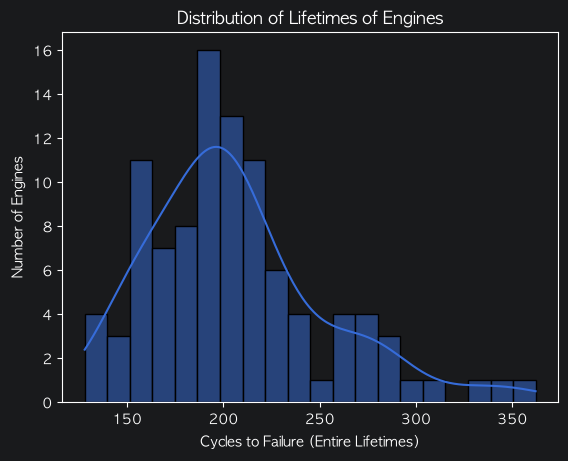

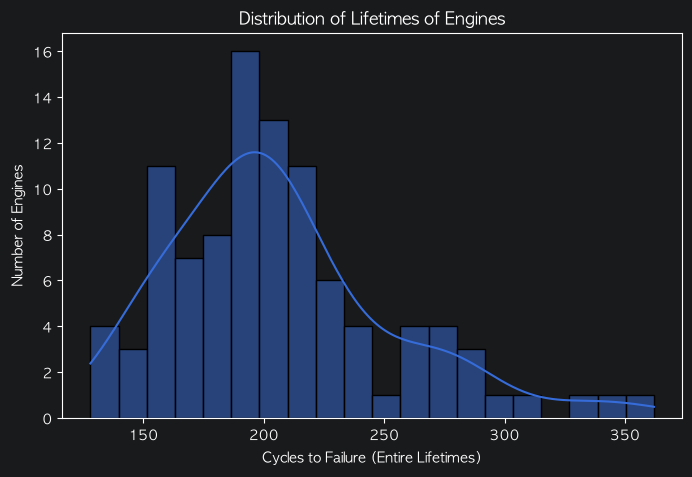

In [126]:
import matplotlib.pyplot as plt

# 맥(Mac)용 기본 한글 폰트(애플고딕) 설정
plt.rc('font', family='AppleGothic')
# 그래프에서 마이너스(-) 기호가 깨지는 문제 해결
plt.rcParams['axes.unicode_minus'] = False

def get_unit_lifetimes(df: pd.DataFrame) -> pd.Series:
    #각 unit의 최대 cycle = 그 엔진의 전체 수명(고장 시점)
    return df.groupby("unit")["cycle"].max()

print(get_unit_lifetimes(df))

lifetimes = get_unit_lifetimes(df)

sns.histplot(lifetimes, bins=20,kde=True)
plt.xlabel("Cycles to Failure (Entire Lifetimes)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Lifetimes of Engines")

def plot_lifetimes(lifetimes: pd.Series, save_path: str = None):
    plt.figure(figsize=(8, 5))
    sns.histplot(lifetimes, bins=20, kde=True)
    plt.xlabel("Cycles to Failure (Entire Lifetimes)")
    plt.ylabel("Number of Engines")
    plt.title("Distribution of Lifetimes of Engines")
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

plot_lifetimes(lifetimes)


In [127]:
# EDA part2: Identify dead sensors

print(df[SENSOR_COLS].std().sort_values(ascending=True))

sensor_summary = pd.DataFrame({
    "std": df[SENSOR_COLS].std(),
    "min": df[SENSOR_COLS].min(),
    "max": df[SENSOR_COLS].max(),
    "unique_values": df[SENSOR_COLS].nunique()
}).sort_values("std")

sensor_summary
# Sensor 1,5,6,10,16,18,19 are suspected to dead (1-2 unique values)


sensor_1     0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_10    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


,std,min,max,unique_values
sensor_1,0.000000e+00,518.6700,518.6700,1
sensor_19,0.000000e+00,100.0000,100.0000,1
sensor_18,0.000000e+00,2388.0000,2388.0000,1
sensor_10,0.000000e+00,1.3000,1.3000,1
sensor_16,3.469531e-18,0.0300,0.0300,1
sensor_5,5.329200e-15,14.6200,14.6200,1
sensor_6,1.388985e-03,21.6000,21.6100,2
sensor_15,3.750504e-02,8.3249,8.5848,1918
sensor_8,7.098548e-02,2387.9000,2388.5600,53
sensor_13,7.191892e-02,2387.8800,2388.5600,56


In [128]:
compare_sensors = [
    "sensor_1",   # 거의 확정된 죽은 센서 후보
    "sensor_6",   # 거의 확정된 죽은 센서 후보
    "sensor_15",  # 살아 있는것으로 확정된 센서
    "sensor_3",   # T30, 열화 신호가 보이는 센서
    "sensor_7"    # P30, 열화 신호가 보이는 센서
]

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

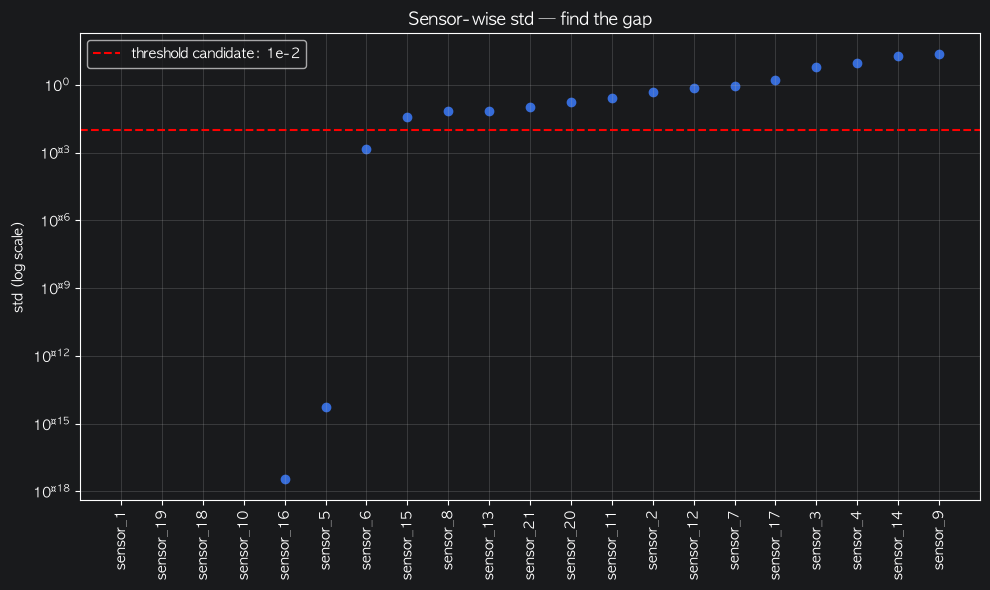

In [129]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(sensor_std)), sensor_std.values)
plt.yscale("log")  # 자릿수 차이가 크므로 로그 스케일
plt.xticks(range(len(sensor_std)), sensor_std.index, rotation=90)
plt.ylabel("std (log scale)")
plt.title("Sensor-wise std — find the gap")
plt.axhline(y=1e-2, color="red", linestyle="--", label="threshold candidate: 1e-2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [130]:
THRESHOLD = 1e-2
near_boundary = sensor_std[(sensor_std > THRESHOLD * 0.1) & (sensor_std < THRESHOLD * 10)]
print("threshold 경계 근처(자릿수 1개 위아래) 센서들 — 이 센서들은 특히 눈으로 재확인 필요:")
print(near_boundary)

threshold 경계 근처(자릿수 1개 위아래) 센서들 — 이 센서들은 특히 눈으로 재확인 필요:
sensor_6     0.001389
sensor_15    0.037505
sensor_8     0.070985
sensor_13    0.071919
dtype: float64


In [131]:
def identify_dead_sensors(sensor_std: pd.Series, threshold: float = 1e-2) -> list:
    return sensor_std[sensor_std < threshold].index.tolist()

dead_sensors = identify_dead_sensors(sensor_std, threshold=THRESHOLD)
print(f"threshold={THRESHOLD} basis, provisional dead sensors {len(dead_sensors)}:")
print(dead_sensors)

threshold=0.01 basis, provisional dead sensors 7:
['sensor_1', 'sensor_19', 'sensor_18', 'sensor_10', 'sensor_16', 'sensor_5', 'sensor_6']


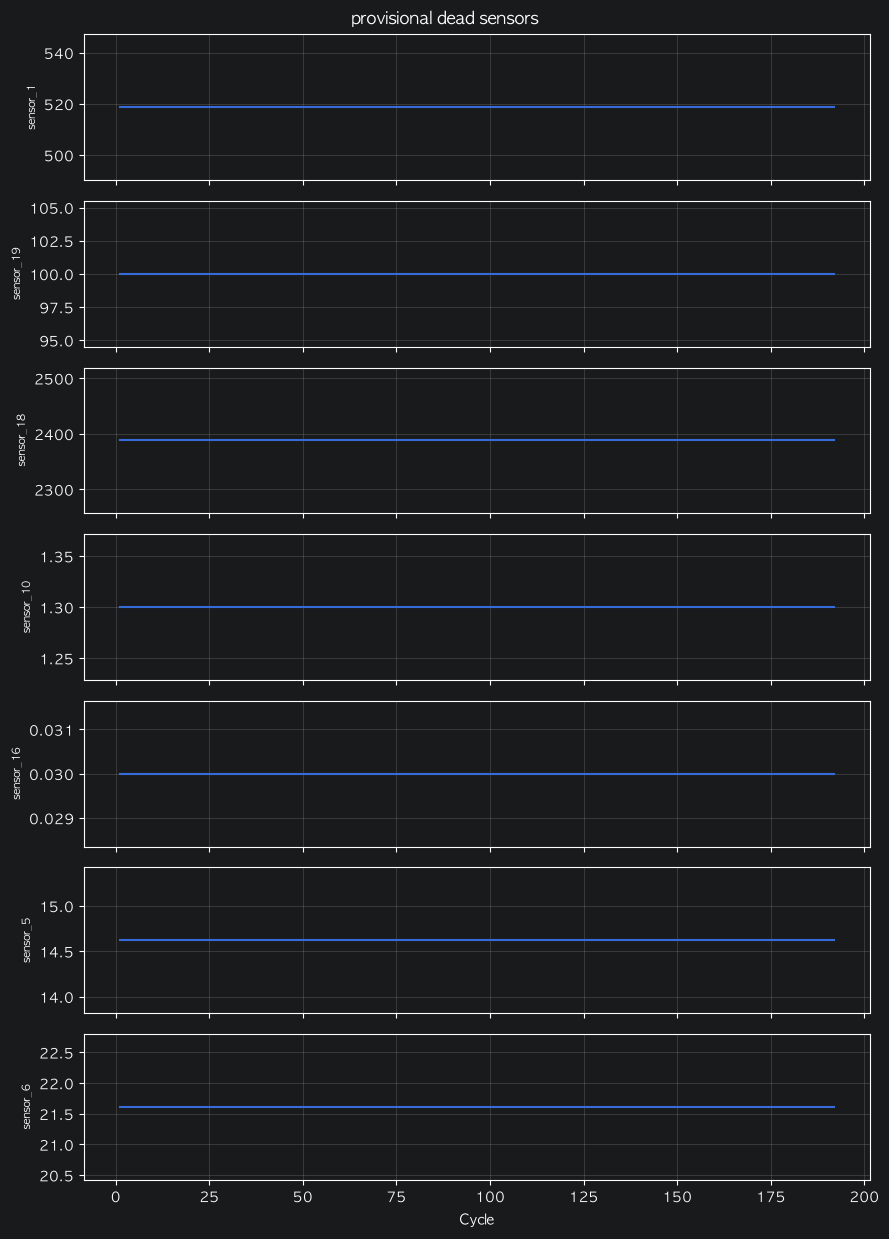

In [132]:
if dead_sensors:
    unit1 = df[df["unit"] == 1]
    n = len(dead_sensors)
    fig, axes = plt.subplots(n, 1, figsize=(9, 1.8 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, sensor in zip(axes, dead_sensors):
        ax.plot(unit1["cycle"], unit1[sensor])
        ax.set_ylabel(sensor, fontsize=8)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("Cycle")
    fig.suptitle("provisional dead sensors")
    plt.tight_layout()
    plt.show()
else:
    print("no provisional dead sensors — may increase the threshold")



Active sensors to visualize (up to 6): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9']


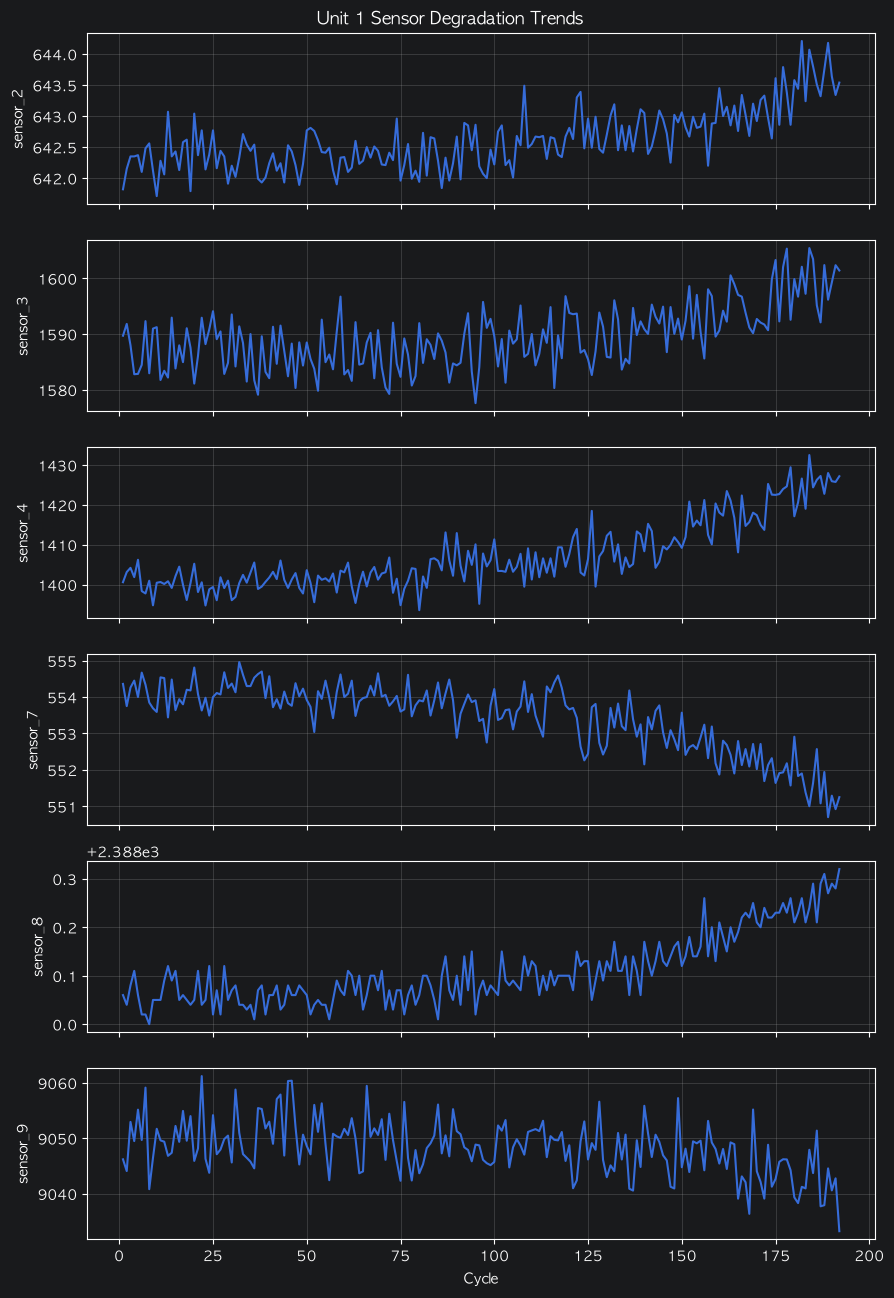

In [133]:
def plot_sensor_trends(df: pd.DataFrame, unit_id: int, sensors: list, save_path: str = None):
    unit_df = df[df["unit"] == unit_id]
    n = len(sensors)
    fig, axes = plt.subplots(n, 1, figsize=(9, 2.2 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, sensor in zip(axes, sensors):
        ax.plot(unit_df["cycle"], unit_df[sensor])
        ax.set_ylabel(sensor)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("Cycle")
    fig.suptitle(f"Unit {unit_id} Sensor Degradation Trends")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

active_sensors = [s for s in SENSOR_COLS if s not in dead_sensors][:6]
print("Active sensors to visualize (up to 6):", active_sensors)
plot_sensor_trends(df, unit_id=1, sensors=active_sensors)

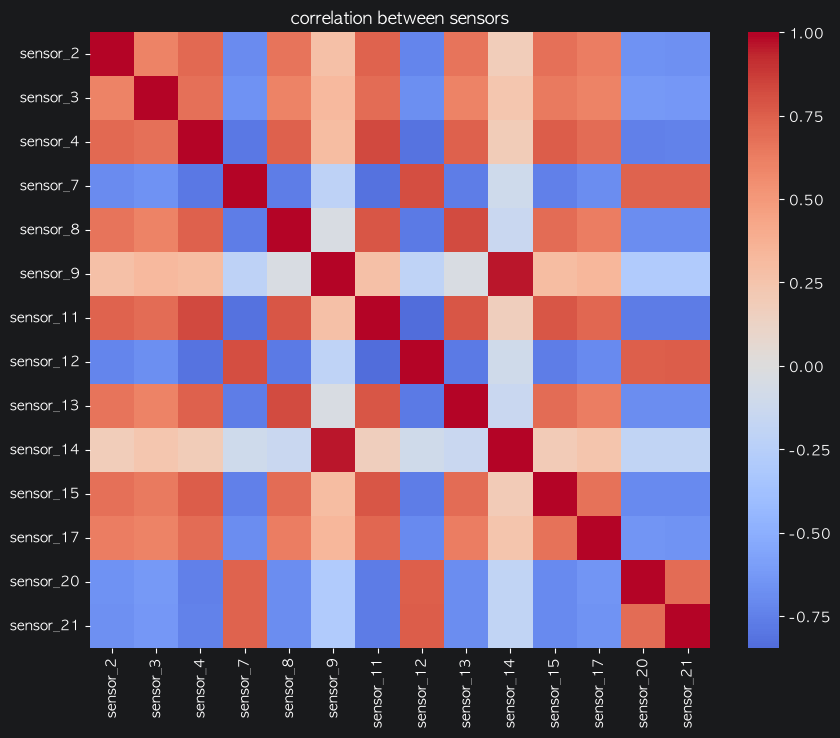

In [134]:
def plot_sensor_correlation(df: pd.DataFrame, sensors: list, save_path: str = None):
    corr = df[sensors].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("correlation between sensors")
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

active_sensors_all = [s for s in SENSOR_COLS if s not in dead_sensors]
plot_sensor_correlation(df, sensors=active_sensors_all)